## 各船の船舶ログから偏流を計算するまでの流れ
1. 複数のログファイルをFileConection.ipynbで１つのファイルにする
1. S1-ShipLogToS1でファイルから必要な情報を抜き出す
1. このファイル(環境省の船舶ログから偏流)で各船の偏流を計算

## import files

In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
from tqdm import tqdm
import pickle as pkl
import math
import os 
import os.path as osp
import re

import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", color_codes=True)

from utils import *
from kf_params import *

## 関数の定義

In [35]:
def latlon_to_mesh_df(lat, lon, deg_per_mesh=1/36, size=[1050, 1191], latlon_range=[20-1/36, 117-1/36]):
    # lat, lon -> [lon, lat]
    grid0 = ((lon-latlon_range[1]).astype(int)/deg_per_mesh)
    grid1 = ((lat-latlon_range[0]).astype(int)/deg_per_mesh)
    grid0[grid0 < 0] = -1
    grid0[grid0 > size[0]] = -1
    grid1[grid1 < 0] = -1
    grid1[grid1 > size[1]] = -1
    return grid0, grid1

def mean_ground_speed(dt, lat1, lon1, lat2, lon2):
    
    lat1 = dms_to_deg(lat1)
    lon1 = dms_to_deg(lon1)
    
    lat2 = dms_to_deg(lat2)
    lon2 = dms_to_deg(lon2)
    
    dist, deg = dist_deg_latlon(lat1, lon1, lat2, lon2)
    speed = dist/dt
    return ((lat1+lat2)/2, (lon1+lon2)/2), (speed, deg)

def dist_deg_latlon(lat1, lon1, lat2, lon2):
    from geopy.distance import geodesic
    res = geodesic((lat1, lon1), (lat2, lon2))
    
    # 方位角を計算
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    delta_lon = lon2_rad - lon1_rad
    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
    bearing = math.degrees(math.atan2(y, x))

    # 0から360度の範囲に調整
    bearing = (bearing + 360) % 360
    return res.meters, bearing

def dms_to_deg(x):
    deg = x // 100
    mit = x - deg*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60

def deg_to_rat(deg):
    #  北基準のdef
    return (-deg+90)*np.pi/180

def remove_outlier(df, key):
    # 下位・上位５％のデータを消す（外れ値対策）
    q1 = df[key].quantile(0.05)
    q2 = df[key].quantile(0.95)
    tf = (df[key]>q1) & (df[key]<q2)
    df2 = df[tf]
    return df2
    

In [3]:
dt_year = 2015
dt_month = 12
dt_day = 30

path = r"E:\shunsukeE\data\test/data/shipLog/"
files = os.listdir(path)
dirs = [f for f in files if os.path.isdir(os.path.join(path, f))]

patterns = []
patterns.append(fr'(\w+){dt_month:02}{dt_day:02}.1..slog1')
forbid_patterns = [fr'(\w+).1..slog1err']

log_datas = []
path_name = []
path_logs = []
for d in dirs:
    path2 = osp.join(path, d)
    files = os.listdir(path2)
    filenames = [f for f in files if os.path.isfile(osp.join(path2, f))]
    for pattern in patterns:
        for f in filenames:
            if re.match(pattern, f):
                forbid = False
                for forbid_pattern in forbid_patterns:
                    if re.match(forbid_pattern, f):
                       forbid = True
                       break
                if not forbid:
                    f_path = osp.join(path, d, f)
                    path_name.append(f_path)
                    path_logs.append( osp.join(path, d))
                    print(f_path)
                    log = pd.read_csv(f_path, encoding="cp932", header=None)
                    log.columns = ["UTC", "NMEA", "data1", "data2"]
                    log_datas.append(log)
                
            else:
                continue


E:\shunsukeE\data\test/data/shipLog/11和光\第十一和光丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/18英山\第十八英山丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/21東\第二十一東丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/2辰巳\第二辰巳丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/33東洋\第三十三東洋丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/87東洋\第八十七東洋丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/MARS\SUNNYMARSFileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/ひま2\ひまわり２FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/中春\中春丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/八菱\第八菱洋丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/双信\双信丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/如月\如月丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/昇山\昇山丸FileOut20151230(1).slog1
E:\shunsukeE\data\test/data/shipLog/昭建\昭建丸FileOut20151230(1).slog1
E:\shunsukeE\data\te

In [4]:
log_datas[0]

,UTC,NMEA,data1,data2
0,2015/12/29 15:00:00,GGA,4224.3161,14137.0193
1,2015/12/29 15:00:00,VBW,12.8000,-999.0000
2,2015/12/29 15:00:00,VHW,-999.0000,12.8000
3,2015/12/29 15:00:00,VTG,4.4000,13.1000
4,2015/12/29 15:00:00,HDT,4.0000,NaN
...,...,...,...,...
383485,2015/12/30 14:59:59,GGA,4205.2818,14126.6181
383486,2015/12/30 14:59:59,HDT,177.0000,NaN
383487,2015/12/30 14:59:59,VTG,174.4000,13.7000
383488,2015/12/30 14:59:59,VBW,13.7000,-999.0000


In [5]:
for i in range(len(log_datas)):
    log_data = log_datas[i]
    print(f'--------num data--------')
    print(f"FileName: {path_name[i]}")
    print(f'GGA: {len(log_data[log_data["NMEA"]=="GGA"])}')
    print(f'VBW: {len(log_data[log_data["NMEA"]=="VBW"])}')
    print(f'HDT: {len(log_data[log_data["NMEA"]=="HDT"])}')
    print(f'VTG: {len(log_data[log_data["NMEA"]=="VTG"])}')
    print(f'VHW: {len(log_data[log_data["NMEA"]=="VHW"])}')
    print(f'------------------------\n')

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/11和光\第十一和光丸FileOut20151230(1).slog1
GGA: 86075
VBW: 39187
HDT: 86074
VTG: 86065
VHW: 86089
------------------------

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/18英山\第十八英山丸FileOut20151230(1).slog1
GGA: 169792
VBW: 84535
HDT: 83803
VTG: 169692
VHW: 0
------------------------

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/21東\第二十一東丸FileOut20151230(1).slog1
GGA: 183494
VBW: 85633
HDT: 97783
VTG: 183879
VHW: 86146
------------------------

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/2辰巳\第二辰巳丸FileOut20151230(1).slog1
GGA: 173408
VBW: 0
HDT: 87328
VTG: 173375
VHW: 0
------------------------

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/33東洋\第三十三東洋丸FileOut20151230(1).slog1
GGA: 98371
VBW: 86387
HDT: 98371
VTG: 182062
VHW: 0
------------------------

--------num data--------
FileName: E:\shunsukeE\data\test/data/shipLog/

In [6]:
def divide_nmea(log_data):
    # 時間の整理　dtIdx: 0時からの経過時間，dtIdx_Minute:0時0分からの経過分
    time_utc =log_data["UTC"].values
    str_format = '%Y/%m/%d %H:%M:%S'
    epoc_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
    time_idx = []
    time_idx2 = []
    tf = []
    for t in time_utc:
        idx = datetime.datetime.strptime(t, str_format) 
        idx2 = idx - epoc_dt
        time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
        time_idx2.append(int(idx2.days*24*60 + idx2.seconds / (60)))
    time_idx = np.array(time_idx)
    time_idx2 = np.array(time_idx2)
    log_data["DtIdx"] = time_idx
    log_data["DtIdx_Minute"] = time_idx2

    # NMEAデータの抽出
    # ggaデータの抽出
    gga = log_data[log_data["NMEA"]=="GGA"]
    gga.columns = ['UTC', 'NMEA', 'LatDMS', 'LonDMS', 'DtIdx', 'DtIdx_Minute']
    gga['Lat'] = dms_to_deg(gga['LatDMS'])
    gga['Lon'] = dms_to_deg(gga['LonDMS'])

    # vbwデータの抽出
    vbw = log_data[log_data["NMEA"]=="VBW"]
    vbw.columns = ['UTC', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx', 'DtIdx_Minute']

    
    # hdtデータの抽出
    hdt = log_data[log_data["NMEA"]=="HDT"]
    hdt = hdt.drop('data2', axis=1)
    hdt.columns = ['UTC', 'NMEA', 'HeadDeg', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出
    vtg = log_data[log_data["NMEA"]=="VTG"]
    vtg.columns = ['UTC', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出
    vhw = log_data[log_data["NMEA"]=="VHW"]
    vhw.columns = ['UTC', 'NMEA', 'HeadDeg', 'WaterSpeed', 'DtIdx', 'DtIdx_Minute']
    
    # データ処理
    # ggaデータ処理
    delete_time_gga = []
    time_set = sorted(set(gga["DtIdx_Minute"]))
    delete_range = 10
    thres = 25 #knot
    for i in range(len(time_set)-1):
            gga1 = gga[time_set[i] == gga["DtIdx_Minute"]]
            gga2 = gga[time_set[i+1] == gga["DtIdx_Minute"]]

            lat1 = np.mean(remove_outlier(gga1, 'Lat')['Lat'])
            lon1 = np.mean(remove_outlier(gga1, 'Lon')['Lon'])
            lat2 = np.mean(remove_outlier(gga2, 'Lat')['Lat'])
            lon2 = np.mean(remove_outlier(gga2, 'Lon')['Lon'])
            
            distance = haversine_distance(lat1, lon1, lat2, lon2)/60
            knot = (distance/(time_set[i+1]-time_set[i])) * 1.94384
            #print(f'value: {knot}, time:{time}')

            time = time_set[i]
            if np.abs(knot)>thres:
                #print(f'value: {knot}, time:{time}')
                delete_time_gga.append(time)
                for j in range(1, 10):
                    delete_time_gga.append(time-j)
                    delete_time_gga.append(time+j)


    # vbwのデータ処理
    values_set = set((vbw["LonWaterSpeed"]).astype(str) + " " 
                 + vbw["TraWaterSpeed"].astype(str))

    forbidden_values = {'0.0 0.0', '0.0 -999.0', '-999.0 0.0', '-999.0 -999.0'}
    dtIdx = []
    dtIdx_m = []
    lonSpeed = []
    traSpeed = []
    for v in values_set:
        tf = (v == (vbw["LonWaterSpeed"]).astype(str) + " " 
                    + vbw["TraWaterSpeed"].astype(str))
        if not v in forbidden_values:
            dtIdx.append(vbw[tf]['DtIdx'].values.tolist())
            dtIdx_m += vbw[tf]['DtIdx_Minute'].values.tolist()
            ls = vbw[tf]['LonWaterSpeed'].values
            ls[ls==-999.0] = 0.0
            lonSpeed.append(ls.tolist())
            ts = vbw[tf]['TraWaterSpeed'].values
            ts[ts==-999.0] = 0.0
            traSpeed.append(ts.tolist())

    dtIdx = sum(dtIdx, [])
    lonSpeed = sum(lonSpeed, [])
    traSpeed = sum(traSpeed, [])

    vbw2 = pd.DataFrame([])
    vbw2['DtIdx'] = dtIdx
    vbw2['DtIdx_Minute'] = dtIdx_m
    vbw2['LonWaterSpeed'] = lonSpeed
    vbw2['TraWaterSpeed'] = traSpeed
    prev_dt = set(vbw['DtIdx_Minute'].values)
    vbw = vbw2
    delete_time_vbw = list(prev_dt - set(vbw['DtIdx_Minute'].values))
    
    # hdtデータ処理
    delete_time_hdt = []
    time_set = sorted(set(hdt["DtIdx_Minute"]))
    delete_range = 10
    thres = (10/180)*np.pi
    for i in range(len(time_set)-1):
            hdt1 = hdt[time_set[i] == hdt["DtIdx_Minute"]]
            hdt2 = hdt[time_set[i+1] == hdt["DtIdx_Minute"]]
            
            hdt1 = remove_outlier(hdt1, 'HeadDeg')
            hdt2 = remove_outlier(hdt2, 'HeadDeg')
            
            headRat1 = deg_to_rat(hdt1['HeadDeg'])
            sin1 = np.mean(np.sin(headRat1))
            cos1 = np.mean(np.cos(headRat1))
            
            headRat2 = deg_to_rat(hdt2['HeadDeg'])
            sin2 = np.mean(np.sin(headRat2))
            cos2 = np.mean(np.cos(headRat2))

            delta_theta = np.arccos(sin1*sin2 + cos1*cos2)
            omega = delta_theta/(time_set[i+1]-time_set[i])
            
            time = time_set[i]
            if np.abs(omega)>thres:
                delete_time_hdt.append(time)
                for j in range(1, 10):
                    delete_time_hdt.append(time-j)
                    delete_time_hdt.append(time+j)

    # vhwデータ処理
    tf = vhw['WaterSpeed']==-999.0
    vhw[tf] = 0.0
    tf = vhw['WaterSpeed']!=0.0
    prev_dt = set(vhw['DtIdx_Minute'].values)
    vhw = vhw[tf]
    delete_time_vhw = list(prev_dt - set(vhw['DtIdx_Minute'].values))
    
    return gga, vbw, hdt, vtg, vhw, delete_time_gga, delete_time_vbw, delete_time_hdt, delete_time_vhw


In [ ]:
# ggas = []
# vbws = []
# hdts = []
# vtgs = []
# vhws = []
# delete_times = []
# delete_times_gga = []
# delete_times_vbw = []
# delete_times_hdt = []
# delete_times_vhw = []

# for i in range(len(log_datas)):
#     gga, vbw, hdt, vtg, vhw,  delete_time_gga, delete_time_vbw, delete_time_hdt, delete_time_vhw = divide_nmea(log_datas[i])
#     ggas.append(gga)
#     vbws.append(vbw)
#     hdts.append(hdt)
#     vtgs.append(vtg)
#     vhws.append(vhw)
#     delete_times_gga.append(delete_time_gga)
#     delete_times_vbw.append(delete_time_vbw)
#     delete_times_hdt.append(delete_time_hdt)
#     delete_times_hdt.append(delete_time_vhw)
#     delete_time = delete_time_gga + delete_time_vbw + delete_time_hdt + delete_time_vhw
#     delete_times.append(delete_time)

In [7]:
ggas = []
vbws = []
hdts = []
vtgs = []
vhws = []
delete_times = []
delete_times_gga = []
delete_times_vbw = []
delete_times_hdt = []
delete_times_vhw = []

i=1
gga, vbw, hdt, vtg, vhw,  delete_time_gga, delete_time_vbw, delete_time_hdt, delete_time_vhw = divide_nmea(log_datas[i])
ggas.append(gga)
vbws.append(vbw)
hdts.append(hdt)
vtgs.append(vtg)
vhws.append(vhw)
delete_times_gga.append(delete_time_gga)
delete_times_vbw.append(delete_time_vbw)
delete_times_hdt.append(delete_time_hdt)
delete_times_hdt.append(delete_time_vhw)
delete_time = delete_time_gga + delete_time_vbw + delete_time_hdt + delete_time_vhw
delete_times.append(delete_time)

In [ ]:
# for i in range(len(delete_times)):
#     delete_times[i] = set(delete_times[i])

## データの確認

In [ ]:
#gga, vbw, hdt, vtg, delete_time_gga, delete_time_vbw, delete_time_hdt = divide_nmea(log_datas[0])

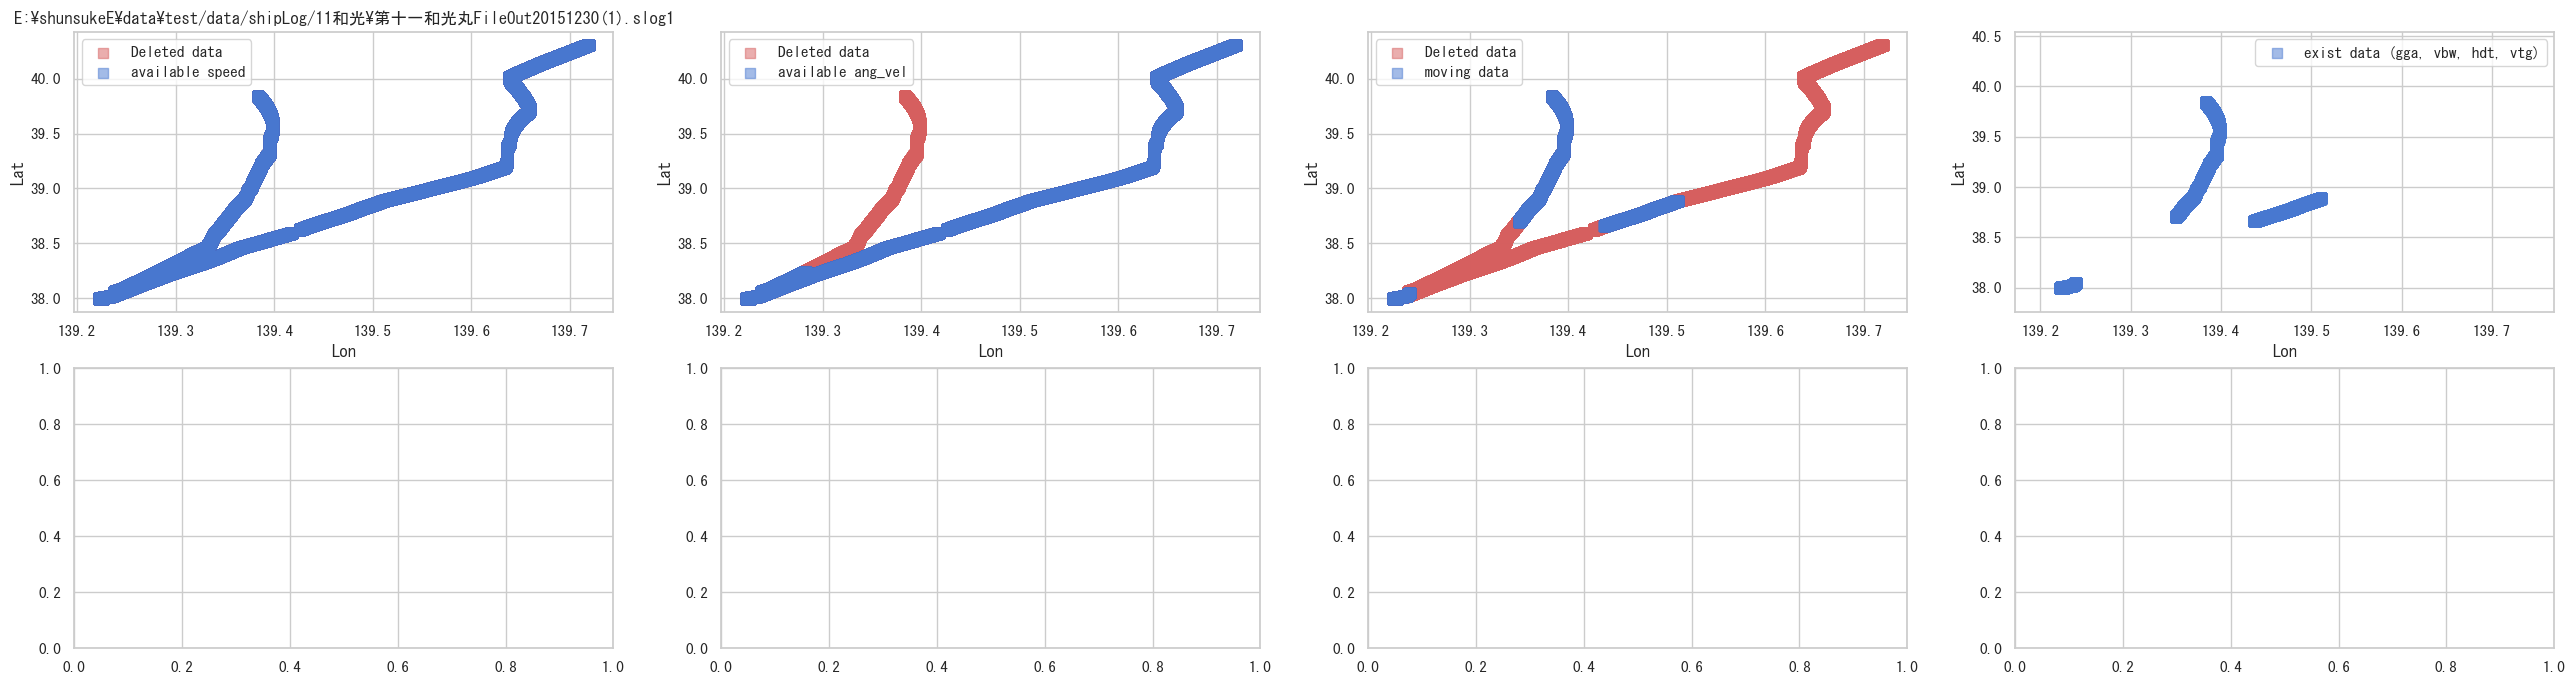

In [10]:
plt.rcParams['font.family'] = 'MS Gothic' 
#fig, axes = plt.subplots(nrows=len(ggas), ncols=4, figsize=(32, 8*len(ggas)))
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 8*len(ggas)))



for i in range(len(ggas)):
    axes[i, 0].set_title(path_name[i])
    for axi in range(3):
        ax = axes[i, axi]
        ggas[i].plot.scatter(x='Lon', y='Lat',
                        marker='s', c='r', s=50, alpha=0.5, ax=ax, label='Deleted data')
    ax = axes[i, 0]
    time_set = set(gga["DtIdx_Minute"])
    gga1 = ggas[i]
    for time in time_set:
        if time in delete_times_gga[i]:
            tf = gga1['DtIdx']!=time
            gga1 = gga1[tf]
    gga1.plot.scatter(x='Lon', y='Lat',
        marker='s', c='b', s=50, alpha=0.5, ax=ax, label='available speed')


    ax = axes[i, 2]
    time_set = set(gga["DtIdx_Minute"])
    gga1 = ggas[i]
    for time in time_set:
        if time in delete_times_vbw[i]:
            tf = gga1['DtIdx']!=time
            gga1 = gga1[tf]
    gga1.plot.scatter(x='Lon', y='Lat',
        marker='s', c='b', s=50, alpha=0.5, ax=ax, label='moving data')

    ax = axes[i, 1]
    time_set = set(gga["DtIdx_Minute"])
    gga1 = ggas[i]
    for time in time_set:
        if time in delete_times_hdt[i]:
            tf = gga1['DtIdx']!=time
            gga1 = gga1[tf]
    gga1.plot.scatter(x='Lon', y='Lat',
        marker='s', c='b', s=50, alpha=0.5, ax=ax, label='available ang_vel')

    ax = axes[i, 3]
    time_set = set(gga["DtIdx_Minute"])
    gga1 = ggas[i]
    limx = (np.max(gga1['Lon'])-np.min(gga1['Lon']))*0.1
    ax.set_xlim(np.min(gga1['Lon'])-limx, np.max(gga1['Lon'])+limx)
    limy = (np.max(gga1['Lat'])-np.min(gga1['Lat']))*0.1
    ax.set_ylim(np.min(gga1['Lat'])-limy, np.max(gga1['Lat'])+limy)
    for time in time_set:
        if (not time in set(vbws[i]["DtIdx_Minute"]) and not time in set(vhws[i]['DtIdx_Minute'])) or \
            not time in set(hdts[i]["DtIdx_Minute"]) or not time in set(vtgs[i]["DtIdx_Minute"]):
            tf = gga1['DtIdx']!=time
            gga1 = gga1[tf]
    gga1.plot.scatter(x='Lon', y='Lat',
        marker='s', c='b', s=50, alpha=0.5, ax=ax, label='exist data (gga, vbw, hdt, vtg)')
plt.show()

In [20]:
tf = gga['DtIdx_Minute']==-539
gga1 = gga[tf]
tf = gga['DtIdx_Minute']==-538
gga2 = gga[tf]

lat1 = np.mean(remove_outlier(gga1, 'Lat')['Lat'])
lon1 = np.mean(remove_outlier(gga1, 'Lon')['Lon'])
lat2 = np.mean(remove_outlier(gga2, 'Lat')['Lat'])
lon2 = np.mean(remove_outlier(gga2, 'Lon')['Lon'])

print(f'{lat1}, {lon1}, {lat2}, {lon2}')



39.84417826984127, 139.38365137540455, 39.840788910256414, 139.38383620915033
disc:377.20981976301067


In [15]:
tf = vtg['DtIdx_Minute']==-539
vtg1 = vtg[tf]
tf = vtg['DtIdx_Minute']==-538
vtg2 = vtg[tf]

gs1 = np.mean(remove_outlier(vtg1, 'GroundSpeed')['GroundSpeed'])
gs2 = np.mean(remove_outlier(vtg1, 'GroundSpeed')['GroundSpeed'])

print(f'{gs1}, {gs2}')

12.100000000000001, 12.100000000000001


In [22]:
# https://tomari.org/main/java/gps5.html#:~:text=%E5%9C%B0%E7%82%B9A(%E7%B5%8C%E5%BA%A6x1,270%E5%BA%A6%E3%81%A7%E8%A1%A8%E7%A4%BA%E3%81%99%E3%82%8B%E3%81%A8%E3%80%82
# 0.37763238km 
x = 0.37763238 * 1000 /60
x_knot = x * 1.94384
print(f'{x_knot}')

dist = haversine_distance(lat1, lon1, lat2, lon2)
print(f'disc:{dist}')
x = dist/60
x_knot = x * 1.94384
print(f'{x_knot}')

12.23428209232
disc:377.20981976301067
12.220592267468843


## 偏流の計算

In [37]:
def cur_nmea(gga, vbw, hdt, vtg, delete_time):
    #各速度の閾値超えたら前後１０分間のデータ捨てる
    #はずれた値のデータも捨てる
    min_timeHours = np.min(gga["DtIdx"])
    max_timeHours = np.max(gga["DtIdx"])
    num_timeHours = max_timeHours - min_timeHours + 1

    grids0 = []
    grids1 = []
    curN = []
    curE = []
    timeMinutes = []
    timeHours = []
    UTC_time = []
    lats = []
    lons = []
    curN_grid = {}
    curE_grid = {}
    count_grid = {}

    time_set_h = set(gga["DtIdx"])
    for s in time_set_h:
        curN_grid[s] = np.zeros(nan_map.shape)
        curE_grid[s] = np.zeros(nan_map.shape)
        count_grid[s] = np.zeros(nan_map.shape) 

    time_set = set(gga["DtIdx_Minute"])
    for time in time_set:
        if time in delete_time:
            continue
        # 時間ごとの平均で偏流を求める
        gga1 = gga[time == gga["DtIdx_Minute"]]
        vbw1 = vbw[time == vbw["DtIdx_Minute"]]
        hdt1 = hdt[time == hdt["DtIdx_Minute"]]
        vtg1 = vtg[time == vtg["DtIdx_Minute"]]
        print('------------------------------')
        if (len(vbw1)==0 or len(gga1)==0 or len(hdt1)==0 or len(vtg1)==0): 
            if len(vbw1)==0:
                print('nodata vbw')
            if len(gga1)==0:
                print('nodata gga') 
            if len(hdt1)==0:
                print('nodata hdt') 
            if len(vtg1)==0:
                print('nodata vtg') 
            continue

        # GGAからLat Lon 取得
        # 分位数95%の値（）
        lat1 = np.mean(remove_outlier(gga1, 'Lat')['Lat'])
        lon1 = np.mean(remove_outlier(gga1, 'Lon')['Lon'])
        # データ数が少なすぎると、外れ値消去の際にnanになる，データが少ないときはその時間は計算せずcontinue
        if not lat1==lat1 or not lon1==lon1:
            print('not enought gga data')
            continue

        # HDTから船首方位取得
        headRat = deg_to_rat(hdt1['HeadDeg'])
        sin1 = np.mean(np.sin(headRat))
        cos1 = np.mean(np.cos(headRat))
        

        # VBWから対船水速取得
        #water_speed = np.mean(vbw1["LonWaterSpeed"].values)
        water_speed = np.mean(remove_outlier(vbw1, 'LonWaterSpeed')['LonWaterSpeed'])
        if water_speed<=0.5:
            continue
        if not water_speed==water_speed:
            print('not enought vbw data')
            continue

        # VTGから船首方位・対地船速取得
        g_headRat = deg_to_rat(vtg1['HeadDeg'])
        g_sin1 = np.mean(np.sin(g_headRat))
        g_cos1 = np.mean(np.cos(g_headRat))
        ground_speed = np.mean(remove_outlier(vtg1, 'GroundSpeed')['GroundSpeed'])
        if not ground_speed==ground_speed:
            print('not enought vtg data')
            continue

        # 偏流の計算
        print(f'ground_speed:{ground_speed}, water_speed:{water_speed}')
        raw = hdt1['HeadDeg'].values[0]
        g_raw = vtg1['HeadDeg'].values[0]
        print(f'ground_rat_raw:{g_raw}, water_rat_raw:{raw}')
        print(f'ground_sin:{g_sin1}, water_sin:{sin1}')
        print(f'ground_cos:{g_cos1}, water_cos:{cos1}')
        curN.append(ground_speed*g_sin1 - water_speed*sin1)
        curE.append(ground_speed*g_cos1 - water_speed*cos1)

        # Gridの位置計算
        grid0, grid1 = latlon_to_mesh(lat1, lon1)

        grids0.append(grid0)
        grids1.append(grid1)
        lats.append(lat1)
        lons.append(lon1)

        UTC_time.append(gga1['UTC'].values[-1][:-6])
        timeMinutes.append(time)
        timeHours.append(gga1['DtIdx'].values[-1])
        curN_grid[timeHours[-1]][grid0][grid1] += curN[-1]
        curE_grid[timeHours[-1]][grid0][grid1] += curE[-1]
        count_grid[timeHours[-1]][grid0][grid1] += 1
        print('------------------------------')

    grid_cur_m = pd.DataFrame([])
    grid_cur_m["DtIdx"] = timeHours
    grid_cur_m["DtIdx_Minute"] = timeMinutes
    grid_cur_m["UTC"] = UTC_time
    grid_cur_m["CurN"] = curN
    grid_cur_m["CurE"] = curE
    grid_cur_m["Grid0"] = grids0
    grid_cur_m["Grid1"] = grids1
    grid_cur_m["Lat"] = lats
    grid_cur_m["Lon"] = lons

    for i in time_set_h:
        count_grid[i][count_grid[i] == 0] += 1
        curN_grid[i] = curN_grid[i]/count_grid[i]
        curE_grid[i] = curE_grid[i]/count_grid[i]
    return grid_cur_m, curN_grid, curE_grid


------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
------------------------------
not enought vbw data
------------------------------
------------------------------
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
not enought vbw data
------------------------------
------------------------------
------------------------------
------------------------------
------------------------------
------------------------------
------------------------------
------------------------------
------------------------------
-------------------------

------------------------------
ground_speed:13.299009900990104, water_speed:11.409615384615384
ground_rat_raw:13.7, water_rat_raw:10.0
ground_sin:0.9715787570759457, water_sin:0.9853295583930111
ground_cos:0.23669441298040136, water_cos:0.17043615184243974
------------------------------
------------------------------
ground_speed:13.559047619047613, water_speed:11.929411764705883
ground_rat_raw:13.3, water_rat_raw:10.0
ground_sin:0.9736307940246626, water_sin:0.9857068865653572
ground_cos:0.22811788741264447, water_cos:0.16821041245439078
------------------------------
------------------------------
not enought vtg data
------------------------------
ground_speed:13.599999999999998, water_speed:11.835849056603772
ground_rat_raw:12.7, water_rat_raw:10.0
ground_sin:0.9752724896230056, water_sin:0.9862994858676538
ground_cos:0.22099015839118766, water_cos:0.16473393362810393
------------------------------
------------------------------
not enought vtg data
------------------------------
g

ground_speed:13.899999999999997, water_speed:11.98627450980392
ground_rat_raw:12.8, water_rat_raw:9.0
ground_sin:0.9750939038993677, water_sin:0.9847880820625937
ground_cos:0.2217725643104541, water_cos:0.17364470914777727
------------------------------
------------------------------
ground_speed:14.059756097560971, water_speed:12.857407407407413
ground_rat_raw:13.1, water_rat_raw:10.0
ground_sin:0.9741397201630018, water_sin:0.9844850746294129
ground_cos:0.22593412590590625, water_cos:0.17533439269026674
------------------------------
------------------------------
not enought vtg data
------------------------------
ground_speed:14.299999999999999, water_speed:12.722916666666668
ground_rat_raw:13.0, water_rat_raw:10.0
ground_sin:0.9741023482820679, water_sin:0.9827595685455658
ground_cos:0.22608833528056957, water_cos:0.18461698953364783
------------------------------
------------------------------
ground_speed:14.299999999999999, water_speed:12.61764705882353
ground_rat_raw:13.3, wat

ground_speed:13.799999999999999, water_speed:12.739622641509435
ground_rat_raw:14.4, water_rat_raw:11.0
ground_sin:0.9708276639158505, water_sin:0.983308536557955
ground_cos:0.23970116181702097, water_cos:0.18165365315133053
------------------------------
------------------------------
ground_speed:13.600000000000001, water_speed:11.806
ground_rat_raw:13.6, water_rat_raw:12.0
ground_sin:0.9696749731601397, water_sin:0.973916283792464
ground_cos:0.2442346970282446, water_cos:0.22572906124624675
------------------------------
------------------------------
ground_speed:13.757954545454549, water_speed:12.524528301886797
ground_rat_raw:15.1, water_rat_raw:14.0
ground_sin:0.961899089075816, water_sin:0.9673522723129964
ground_cos:0.2732813717048768, water_cos:0.2532824127000625
------------------------------
------------------------------
ground_speed:13.853750000000002, water_speed:12.518518518518523
ground_rat_raw:16.5, water_rat_raw:15.0
ground_sin:0.9566289534068181, water_sin:0.9663530

ground_speed:14.200000000000005, water_speed:11.98679245283019
ground_rat_raw:15.0, water_rat_raw:12.0
ground_sin:0.9651948951068297, water_sin:0.9779892483387985
ground_cos:0.26152332898985603, water_cos:0.20848285582727732
------------------------------
------------------------------
ground_speed:14.250000000000002, water_speed:13.260416666666666
ground_rat_raw:14.9, water_rat_raw:12.0
ground_sin:0.9668662996453664, water_sin:0.9794814407741179
ground_cos:0.25526153352053754, water_cos:0.20135565756529386
------------------------------
------------------------------
ground_speed:14.5655172413793, water_speed:13.70232558139535
ground_rat_raw:14.6, water_rat_raw:12.0
ground_sin:0.968850885871102, water_sin:0.9797714060002728
ground_cos:0.24763241845970815, water_cos:0.19993043294519267
------------------------------
------------------------------
not enought vtg data
------------------------------
ground_speed:14.424761904761908, water_speed:12.186538461538463
ground_rat_raw:14.9, wate

...

------------------------------
not enought vtg data
------------------------------
ground_speed:13.700000000000003, water_speed:13.580434782608702
ground_rat_raw:183.8, water_rat_raw:186.0
ground_sin:-0.9982330827001442, water_sin:-0.9962298198070989
ground_cos:-0.05932091374443279, water_cos:-0.08439376970960709
------------------------------
------------------------------
not enought vtg data
------------------------------
not enought vtg data
------------------------------
not enought vtg data
------------------------------
not enought vtg data
------------------------------
not enought vtg data
------------------------------
ground_speed:13.400000000000004, water_speed:13.38297872340426
ground_rat_raw:183.4, water_rat_raw:185.0
ground_sin:-0.9979873571292516, water_sin:-0.9958227617631501
ground_cos:-0.06334583885004921, water_cos:-0.0905644487807233
------------------------------
------------------------------
ground_speed:13.47978723404256, water_speed:13.416666666666666
ground_r

ground_speed:13.700000000000003, water_speed:13.79565217391305
ground_rat_raw:184.7, water_rat_raw:186.0
ground_sin:-0.9966941449293291, water_sin:-0.9966948110082107
ground_cos:-0.0812034386529207, water_cos:-0.07969199039194087
------------------------------
------------------------------
ground_speed:13.836458333333335, water_speed:13.880392156862749
ground_rat_raw:184.7, water_rat_raw:183.0
ground_sin:-0.9974712841940027, water_sin:-0.9974222252511616
ground_cos:-0.07084346018194344, water_cos:-0.06974691165032337
------------------------------
------------------------------
not enought vtg data
------------------------------
ground_speed:13.764835164835162, water_speed:13.812244897959186
ground_rat_raw:184.6, water_rat_raw:186.0
ground_sin:-0.9966281652944348, water_sin:-0.9963681311087413
ground_cos:-0.08199711313908539, water_cos:-0.08354646464332961
------------------------------
------------------------------
ground_speed:13.751000000000001, water_speed:13.719148936170217
grou

ground_speed:13.799999999999994, water_speed:13.818181818181824
ground_rat_raw:189.5, water_rat_raw:189.0
ground_sin:-0.9868617112057821, water_sin:-0.985184844453018
ground_cos:-0.16154585015407522, water_cos:-0.17105642337145985
------------------------------
------------------------------
ground_speed:13.700000000000001, water_speed:13.85849056603774
ground_rat_raw:189.3, water_rat_raw:191.0
ground_sin:-0.9865434896343461, water_sin:-0.9852048432517921
ground_cos:-0.16348338007247834, water_cos:-0.17105994969926552
------------------------------
------------------------------
not enought vtg data
------------------------------
ground_speed:13.799999999999999, water_speed:13.94901960784314
ground_rat_raw:189.1, water_rat_raw:190.0
ground_sin:-0.9871028928638705, water_sin:-0.984025645742238
ground_cos:-0.16006574058497186, water_cos:-0.1778680508742125
------------------------------
------------------------------
ground_speed:13.662637362637357, water_speed:13.67058823529412
ground_r

------------------------------
not enought vtg data
------------------------------
ground_speed:14.0, water_speed:13.779591836734696
ground_rat_raw:189.9, water_rat_raw:191.0
ground_sin:-0.9832617159450368, water_sin:-0.981809320103702
ground_cos:-0.1821332519915302, water_cos:-0.18965912863573048
------------------------------
------------------------------
ground_speed:14.100000000000001, water_speed:13.913333333333329
ground_rat_raw:190.9, water_rat_raw:189.0
ground_sin:-0.9818385436590503, water_sin:-0.9834856250726847
ground_cos:-0.1897092023557472, water_cos:-0.18050316619613044
------------------------------
------------------------------
ground_speed:14.200000000000005, water_speed:13.996296296296302
ground_rat_raw:191.0, water_rat_raw:189.0
ground_sin:-0.981712525926463, water_sin:-0.9843847508038035
ground_cos:-0.1903514541761793, water_cos:-0.17534548484934626
------------------------------
------------------------------
not enought vtg data
------------------------------
gr

TypeError: 'Axes' object is not subscriptable

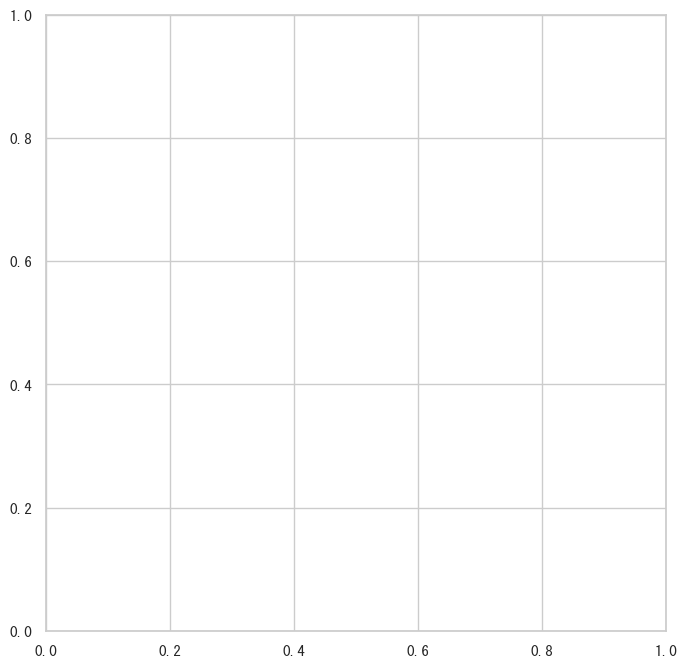

In [38]:
i = 0
grid_cur, N, E = cur_nmea(ggas[i], vbws[i], hdts[i], vtgs[i], delete_times[i])
plt.rcParams['font.family'] = 'MS Gothic' 
fig, axes = plt.subplots(nrows=len(ggas), ncols=1, figsize=(8, 8*len(ggas)))

ax = axes[i]
ggas[i].plot.scatter(x='Lon', y='Lat',
                    marker='s', c='r', s=50, alpha=0.5, ax=ax, label='Deleted data')
grid_cur_minute[i].plot.scatter(x='Lon', y='Lat',
                marker='s', c='b', s=50, alpha=0.5, ax=ax, label='Used data')
ax.set_title(path_name[i])
plt.show()

In [ ]:
grid_cur_minute = []
curN_grid = []
curE_grid = []
for i in range(len(ggas)):
    grid_cur, N, E = cur_nmea(ggas[i], vbws[i], hdts[i], vtgs[i], delete_times[i])
    grid_cur_minute.append(grid_cur)
    curN_grid.append(N)
    curE_grid.append(E)

In [ ]:
plt.rcParams['font.family'] = 'MS Gothic' 
fig, axes = plt.subplots(nrows=len(ggas), ncols=1, figsize=(8, 8*len(ggas)))

for i in range(len(ggas)):
    ax = axes[i]
    ggas[i].plot.scatter(x='Lon', y='Lat',
                        marker='s', c='r', s=50, alpha=0.5, ax=ax, label='Deleted data')
    grid_cur_minute[i].plot.scatter(x='Lon', y='Lat',
                    marker='s', c='b', s=50, alpha=0.5, ax=ax, label='Used data')
    ax.set_title(path_name[i])
plt.show()

In [ ]:
def cur_minute_to_hour(grid_cur_m):
    grids0 = []
    grids1 = []
    curN = []
    curE = []
    timeHours = []
    UTC_time = []
    lats = []
    lons = []

    time_set = set(grid_cur_m["DtIdx"])
    for time in time_set:
        target = grid_cur_m[time == grid_cur_m["DtIdx"]]
        timeHours.append(time)
        UTC_time.append(target["UTC"].values[0])
        lats.append(target.Lat.quantile(0.95))
        lons.append(target.Lon.quantile(0.95))
        grids0.append(int(target.Grid0.quantile(0.95)))
        grids1.append(int(target.Grid1.quantile(0.95)))
        curN.append(target.CurN.quantile(0.95))
        curE.append(target.CurE.quantile(0.95))
    #     lats.append(np.mean(target["Lat"].values))
    #     lons.append(np.mean(target["Lon"].values))
    #     grids0.append(int(np.mean(target["Grid0"].values)))
    #     grids1.append(int(np.mean(target["Grid1"].values)))
    #     curN.append(np.mean(target["CurN"].values))
    #     curE.append( np.mean(target["CurE"].values))
    grid_cur = pd.DataFrame([])
    grid_cur["DtIdx"] = timeHours
    grid_cur["UTC"] = UTC_time
    grid_cur["CurN"] = curN
    grid_cur["CurE"] = curE
    grid_cur["Grid0"] = grids0
    grid_cur["Grid1"] = grids1
    grid_cur["Lat"] = lats
    grid_cur["Lon"] = lons
    return grid_cur

In [ ]:
grid_curs = []
for grid_cur_m in grid_cur_minute:
    grid_cur = cur_minute_to_hour(grid_cur_m)
    grid_curs.append(grid_cur)

## データの保存

In [ ]:
for i in range(len(grid_curs)):
    # 保存
    gird_cur_m = grid_cur_minute[i]
    grid_cur = grid_curs[i]
    grid_cur_m = grid_cur_m.sort_values('DtIdx_Minute')
    grid_cur_m = grid_cur_m.reset_index(drop=True)
    grid_cur = grid_cur.sort_values('DtIdx')
    grid_cur = grid_cur.reset_index(drop=True)

    save_path = osp.join(path_logs[i], f"cur_hours{dt_year}{dt_month:02}{dt_day:02}.csv")
    grid_cur.to_csv(save_path)

    save_path = osp.join(path_logs[i], f"cur_minutes{dt_year}{dt_month:02}{dt_day:02}.csv")
    grid_cur_m.to_csv(save_path)
    
    pkl.dump(curN_grid[i], open(osp.join(path_logs[i], f"curGridN.pkl"), 'wb'))
    pkl.dump(curE_grid[i], open(osp.join(path_logs[i], f"curGridE.pkl"), 'wb'))
    print(save_path)

In [ ]:
# 保存
# keys = grid_cur.keys()
# out = {}
# for k in keys:
#     out[k] = grid_cur[k]

# pkl.dump(out, open(osp.join(path_log, "cur.pkl"), 'wb'))

In [ ]:
# pkl.dump(grid_cur, open(osp.join(path_log, "cur.pkl"), 'wb'))
# pkl.dump(grid_cur_m, open(osp.join(path_log, "cur_minus.pkl"), 'wb'))